# ASL Alphabet Classification Model Training

This notebook handles data loading, preprocessing, and model training

## IMPORT & SETUP

In [2]:
from tensorflow.keras import layers
import tensorflow as tf
import os
import matplotlib.pyplot as plt

# Create training directory if it doesn't exist
os.makedirs('../model_training', exist_ok=True)

## LOAD DATASET

In [3]:
path = "../dataset/asl_alphabet_train/asl_alphabet_train"

In [4]:
dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    image_size=(96,96),
    batch_size=32,
    shuffle=True,
    color_mode="grayscale", # Converts the Images to grayscale
    seed=42
)

class_names = dataset.class_names
print("Classes:", class_names)

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'del', 'nothing', 'space']


## CHECK CLASS BALANCE

In [5]:
for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)

    if os.path.isdir(folder_path):
        num_images = len([
            file for file in os.listdir(folder_path)
            if file.endswith(('.jpg'))
        ])

        print(f"{folder}: {num_images} images")

A: 3000 images
B: 3000 images
C: 3000 images
D: 3000 images
del: 3000 images
E: 3000 images
F: 3000 images
G: 3000 images
H: 3000 images
I: 3000 images
K: 3000 images
L: 3000 images
M: 3000 images
N: 3000 images
nothing: 3000 images
O: 3000 images
P: 3000 images
Q: 3000 images
R: 3000 images
S: 3000 images
space: 3000 images
T: 3000 images
U: 3000 images
V: 3000 images
W: 3000 images
X: 3000 images
Y: 3000 images


## IMAGE VISUALIZATION

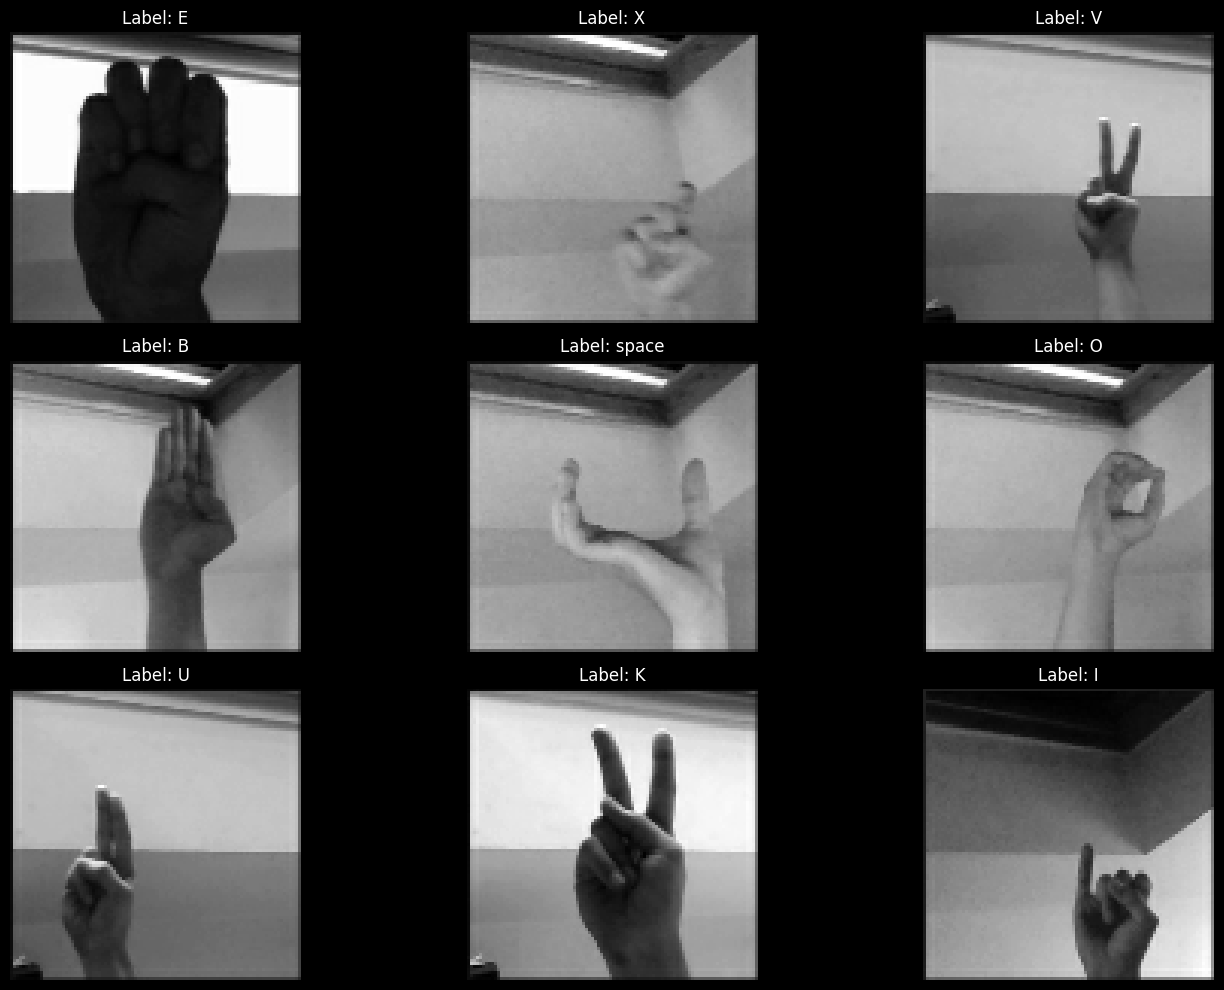

In [6]:
for images, labels in dataset.take(1):
    plt.figure(figsize=(15, 10))

    # Display first 9 images
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.title(f"Label: {class_names[labels[i]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## DATA NORMALIZATION

In [7]:
def normalize(image, labels):
    image = tf.cast(image, tf.float32) / 255.0
    return image, labels

normalized_dataset = dataset.map(normalize)

# Check the first batch
for images, labels in normalized_dataset.take(1):
    print(f"Min value: {tf.reduce_min(images).numpy()}")
    print(f"Max value: {tf.reduce_max(images).numpy()}")
    break

Min value: 0.0003744514542631805
Max value: 1.0


## DATA SPLITTING (80/10/10)

In [13]:
data_size = len(normalized_dataset)

train_size = int(0.8 * data_size)
validation_size = int(0.1 * data_size)
test_size = data_size - train_size - validation_size

train_dataset = normalized_dataset.take(train_size)        # 80%
remaining = normalized_dataset.skip(train_size)            # remaining 20%
validation_dataset = remaining.take(validation_size)       # 10%
test_dataset = remaining.skip(validation_size)             # 10%

print(f"\nDataset split:")
print(f"  Train:      {train_size} batches")
print(f"  Validation: {validation_size} batches")
print(f"  Test:       {test_size} batches")


Dataset split:
  Train:      2025 batches
  Validation: 253 batches
  Test:       254 batches


## DATA AUGMENTATION

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05,0.05),
])

AUTOTUNE = tf.data.experimental.AUTOTUNE

def augment(image, label):
    image = data_augmentation(image, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

train_dataset = train_dataset.map(
    augment, num_parallel_calls=AUTOTUNE).shuffle(1000).prefetch(buffer_size = AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size = AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size = AUTOTUNE)

## MODEL ARCHITECTURE

In [17]:
model = tf.keras.Sequential([

     layers.Input(shape=(96, 96, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.1),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.1),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.1),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.1),

    layers.Flatten(),

    layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation='softmax'),
])

model.summary(print_fn=lambda x: print(x, flush=True))

Model: "sequential_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)

### COMPILE MODEL

In [18]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'],
)

### CALLBACKS SETUP

In [19]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath='../model_outputs/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

### MODEL TRAINING

In [20]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

2025/2025 ━━━━━━━━━━━━━━━━━━━━ 720s 350ms/step - accuracy: 0.9951 - loss: 0.0165 - val_accuracy: 0.9999 - val_loss: 6.8188e-04 - learning_rate: 2.5000e-04


In [23]:
history.history

{'accuracy': [0.2516821026802063,
  0.5573148131370544,
  0.7561110854148865,
  0.8584104776382446,
  0.9001389145851135,
  0.9252314567565918,
  0.9405864477157593,
  0.950709879398346,
  0.9546913504600525,
  0.9615277647972107,
  0.9637500047683716,
  0.9684259295463562,
  0.9718981385231018,
  0.9729166626930237,
  0.9740277528762817,
  0.9761419892311096,
  0.985478401184082,
  0.9880247116088867,
  0.9891666769981384,
  0.9895216226577759,
  0.9919598698616028,
  0.9938580393791199,
  0.9941357970237732,
  0.9943673014640808,
  0.9950617551803589],
 'loss': [2.4280598163604736,
  1.295864224433899,
  0.697916567325592,
  0.4221935272216797,
  0.3032602071762085,
  0.24063090980052948,
  0.19580838084220886,
  0.1609734147787094,
  0.1556062400341034,
  0.1310865730047226,
  0.12791983783245087,
  0.11441200971603394,
  0.09864313900470734,
  0.09858507663011551,
  0.09273400157690048,
  0.08705174177885056,
  0.050388023257255554,
  0.04214062541723251,
  0.036800842732191086,
  

In [24]:
evaluate = model.evaluate(test_dataset,batch_size=32)

254/254 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.9999 - loss: 5.0386e-04


### EXPORT ARTIFACTS

In [25]:
# Saves and Export Datasets
tf.data.experimental.save(train_dataset, '../model_outputs/train_dataset')
tf.data.experimental.save(validation_dataset, '../model_outputs/val_dataset')
tf.data.experimental.save(test_dataset, '../model_outputs/test_dataset')

# Saves class_names
import json
with open('../model_outputs/class_names.json', 'w') as f:
    json.dump(class_names, f)

Instructions for updating:
Use `tf.data.Dataset.save(...)` instead.
